In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("bmw_cars_market_dataset_cleaned.csv")

# Basic info
print(df.shape)
print(df.info())
df.head()


(10000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  float64
 1   model                         10000 non-null  float64
 2   year                          10000 non-null  float64
 3   engine_size                   10000 non-null  float64
 4   horsepower                    10000 non-null  float64
 5   fuel_type                     10000 non-null  float64
 6   transmission                  10000 non-null  float64
 7   drivetrain                    10000 non-null  float64
 8   mileage_km                    10000 non-null  float64
 9   fuel_consumption_l_per_100km  10000 non-null  float64
 10  price_usd                     10000 non-null  float64
 11  co2_emissions_g_km            10000 non-null  float64
 12  doors                         10000 non-null  float64
 13  s

,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,price_usd,co2_emissions_g_km,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold
0,1.0,6.0,2016.0,4.0,272.0,0.0,0.0,0.0,74655.0,8.900000,66756.0,196.0,5.0,5.0,4.0,5.0,2.0,0.0,2.0,3.0
1,2.0,0.0,2022.0,2.6,218.0,3.0,0.0,1.0,23469.0,8.400000,26867.0,190.0,3.0,4.0,2.0,0.0,1.0,0.0,2.0,0.0
2,3.0,4.0,2012.0,2.2,240.0,3.0,0.0,1.0,123273.0,7.800000,31313.0,174.0,5.0,5.0,4.0,5.0,3.0,0.0,0.0,3.0
3,4.0,6.0,2022.0,3.8,316.0,0.0,2.0,0.0,33064.0,9.400000,81594.0,192.0,5.0,5.0,4.0,1.0,1.0,0.0,3.0,0.0
4,5.0,3.0,2023.0,3.1,294.0,3.0,0.0,2.0,23926.0,6.568987,104105.0,204.0,4.0,5.0,3.0,5.0,1.0,0.0,0.0,4.0


In [2]:
# Missing values
print(df.isnull().sum())

# Duplicates
print("Duplicates:", df.duplicated().sum())

# Data types
print(df.dtypes)


car_id                          0
model                           0
year                            0
engine_size                     0
horsepower                      0
fuel_type                       0
transmission                    0
drivetrain                      0
mileage_km                      0
fuel_consumption_l_per_100km    0
price_usd                       0
co2_emissions_g_km              0
doors                           0
seats                           0
body_type                       0
color                           0
owner_count                     0
accident_history                0
service_history                 0
country_sold                    0
dtype: int64
Duplicates: 0
car_id                          float64
model                           float64
year                            float64
engine_size                     float64
horsepower                      float64
fuel_type                       float64
transmission                    float64
drivetrain   

In [3]:
df.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
car_id,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
model,10000.0,4.111900,3.087707,0.0,1.00,4.0,6.00,11.0
year,10000.0,2016.381700,5.442478,2005.0,2012.00,2017.0,2021.00,2024.0
engine_size,10000.0,2.484555,1.186320,0.0,2.00,2.6,3.30,5.0
horsepower,10000.0,269.948600,80.687398,120.0,211.00,260.0,317.00,700.0
fuel_type,10000.0,1.650100,1.197670,0.0,0.00,2.0,3.00,3.0
transmission,10000.0,0.117800,0.383325,0.0,0.00,0.0,0.00,2.0
drivetrain,10000.0,0.929700,0.943741,0.0,0.00,1.0,2.00,2.0
mileage_km,10000.0,112364.794000,86335.775989,0.0,39924.00,94483.0,171752.75,300000.0
fuel_consumption_l_per_100km,10000.0,6.568987,2.984589,0.0,5.50,7.1,8.60,12.9


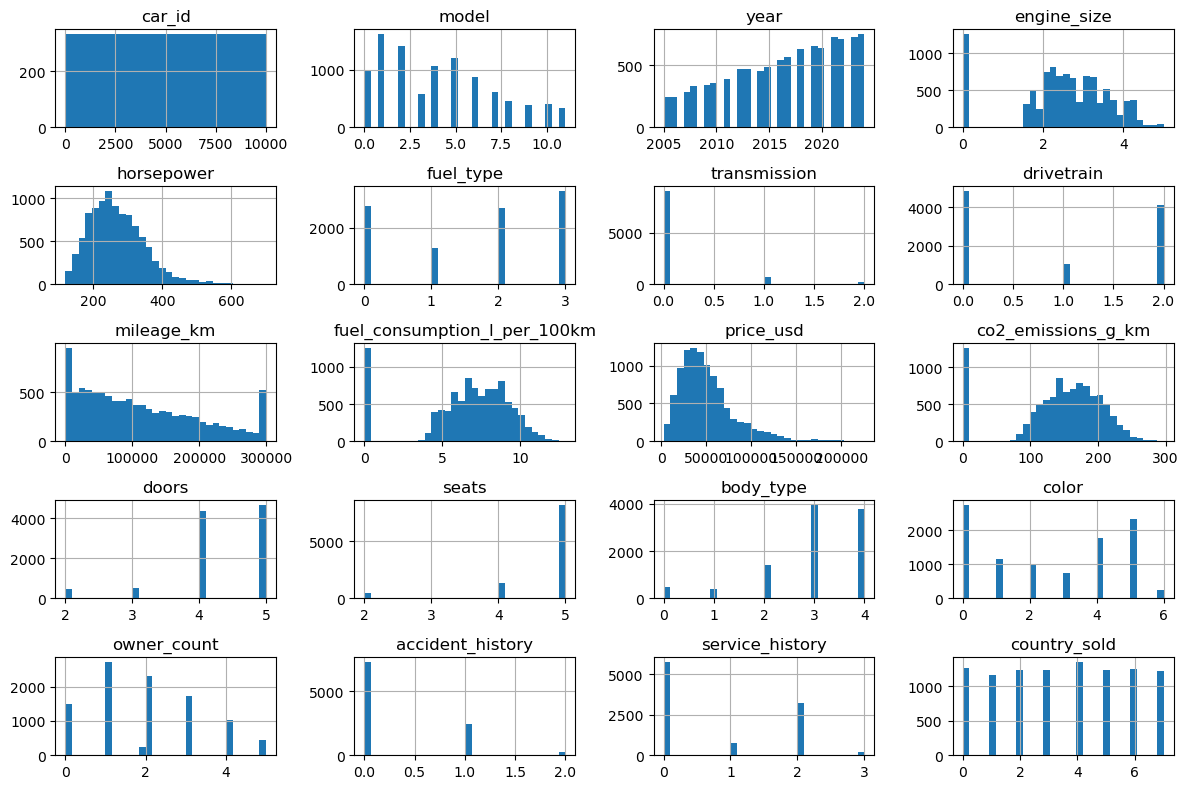

In [4]:
# Numerical distributions
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

# Categorical counts
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()


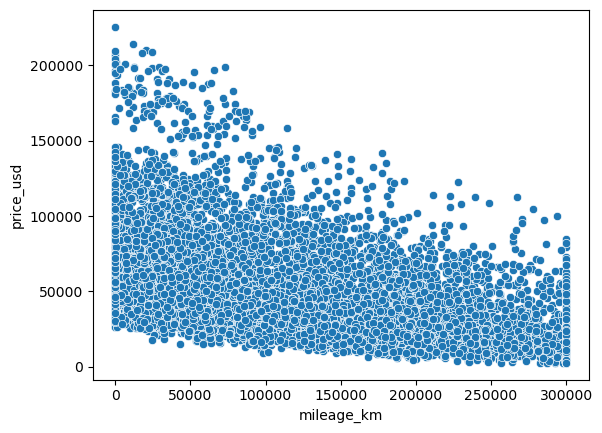

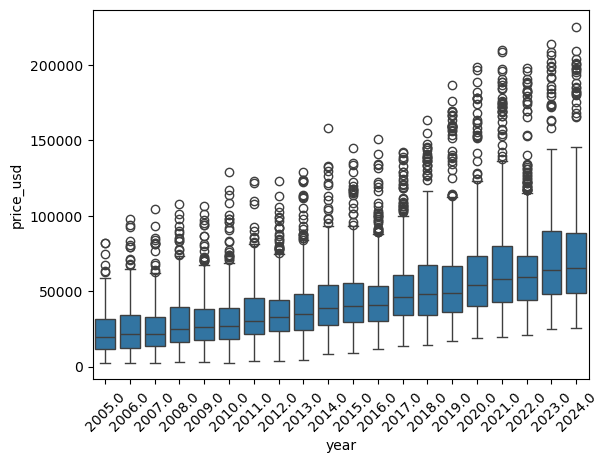

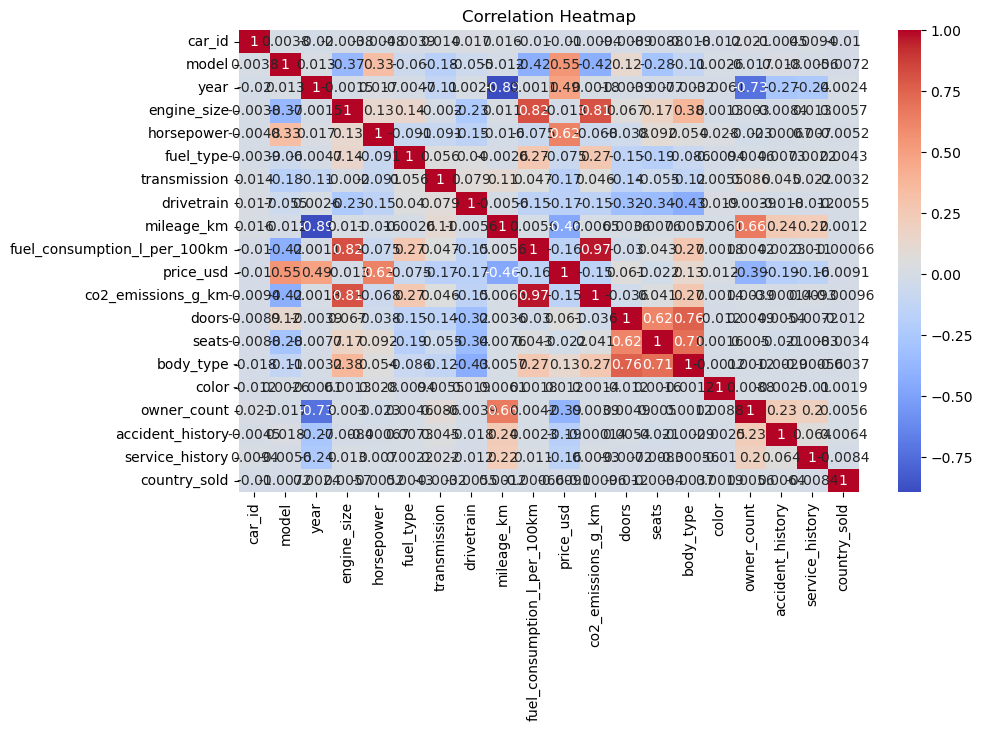

In [9]:
# Price vs Mileage
sns.scatterplot(x="mileage_km", y="price_usd", data=df)
plt.show()

# Price vs Year
sns.boxplot(x="year", y="price_usd", data=df)
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


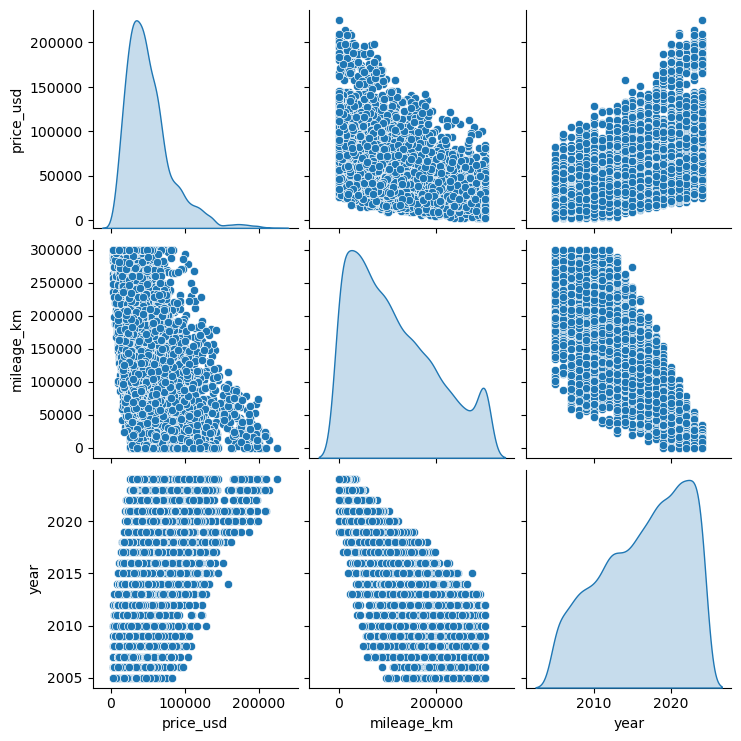

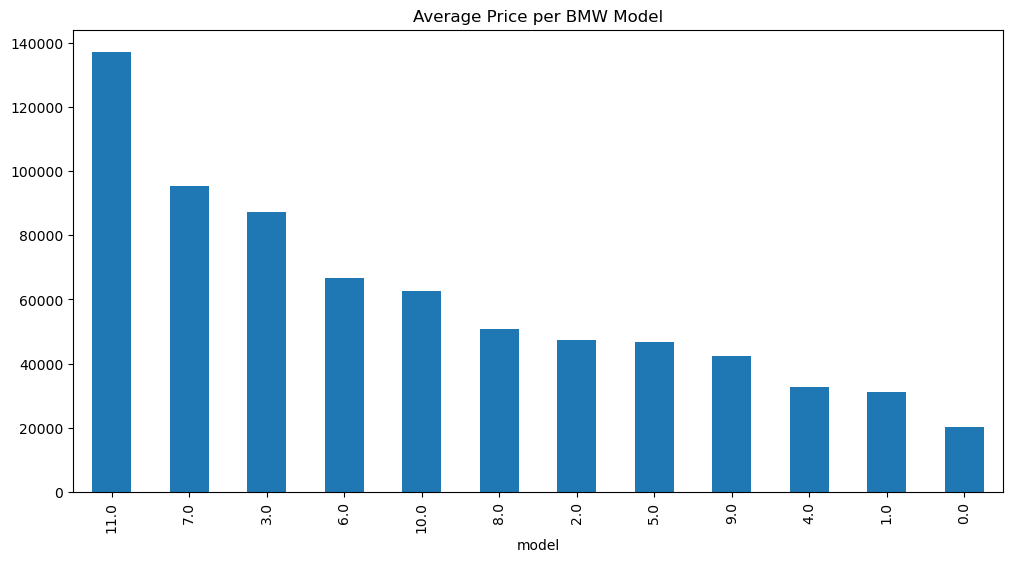

In [11]:
# Pairplot for selected features
sns.pairplot(df[["price_usd", "mileage_km", "year"]], diag_kind="kde")
plt.show()

# Average price per model
avg_price_model = df.groupby("model")["price_usd"].mean().sort_values(ascending=False)
avg_price_model.plot(kind="bar", figsize=(12,6))
plt.title("Average Price per BMW Model")
plt.show()


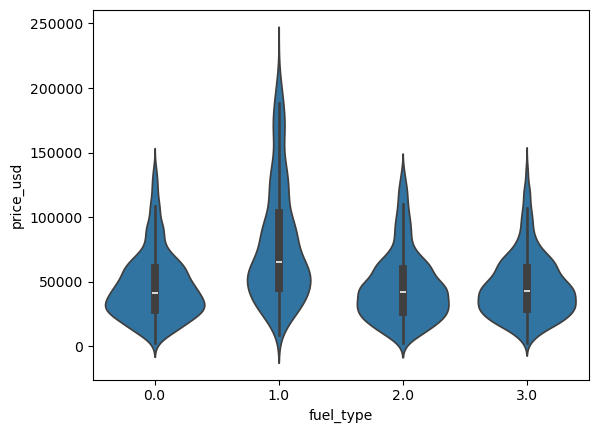

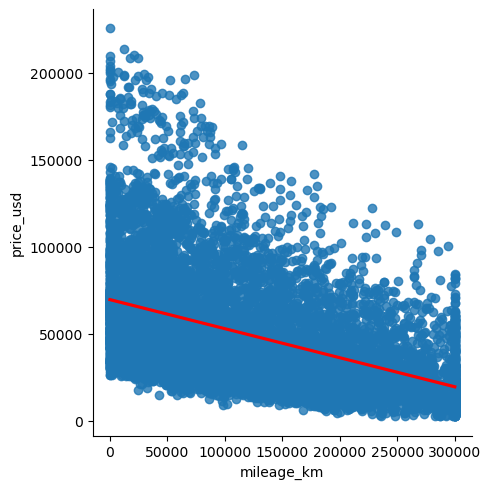

In [14]:
sns.violinplot(x="fuel_type", y="price_usd", data=df)
plt.show()

sns.lmplot(x="mileage_km", y="price_usd", data=df, line_kws={"color":"red"})
plt.show()


In [15]:

import plotly.express as px

df = pd.read_csv("bmw_cars_market_dataset_cleaned.csv")

# Interactive scatter plot: Price vs Mileage
fig = px.scatter(df, x="mileage_km", y="price_usd", color="model",
                 hover_data=["year", "fuel_type", "transmission"])
fig.show()

# Interactive box plot: Price by Year
fig = px.box(df, x="year", y="price_usd", color="fuel_type")
fig.show()
